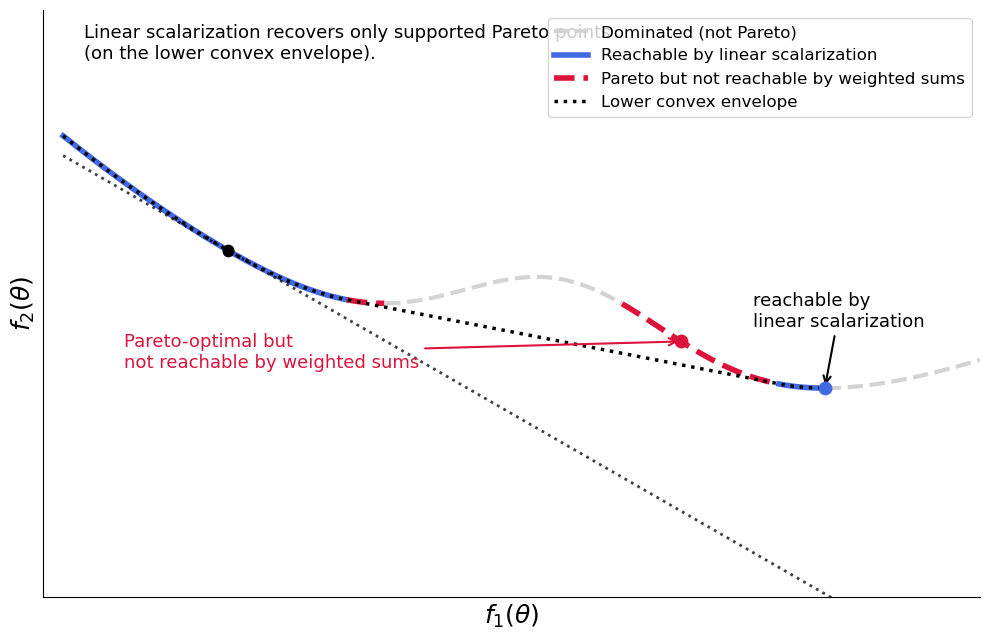

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Continuous curve in objective space
# ============================================================
x = np.linspace(0.7, 5.2, 1200)

y = (
    4.6
    - 0.95 * x
    + 0.18 * (x - 1.3) ** 2
    + 0.75 * np.exp(-((x - 3.15) / 0.75) ** 2)
)

# ============================================================
# 1) Compute Pareto points for minimization
#    Since x increases left->right, a point is nondominated
#    iff its y is strictly lower than all previous y-values.
# ============================================================
pareto_mask = np.zeros_like(x, dtype=bool)
best_y = np.inf
for i in range(len(x)):
    if y[i] < best_y:
        pareto_mask[i] = True
        best_y = y[i]

x_p = x[pareto_mask]
y_p = y[pareto_mask]

# ============================================================
# 2) Compute lower convex hull of Pareto points
#    These are exactly the supported Pareto points.
# ============================================================
def cross(o, a, b):
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

pts = np.column_stack([x_p, y_p])

lower = []
lower_idx = []

for i, p in enumerate(pts):
    while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
        lower.pop()
        lower_idx.pop()
    lower.append(tuple(p))
    lower_idx.append(i)

lower = np.array(lower)
lower_idx = np.array(lower_idx)

# ============================================================
# 3) Classify Pareto points
# ============================================================
supported_mask_p = np.zeros(len(x_p), dtype=bool)
supported_mask_p[lower_idx] = True
unsupported_mask_p = ~supported_mask_p

# Full-curve masks
dominated_mask = ~pareto_mask

# ============================================================
# 4) Build contiguous segments for prettier plotting
# ============================================================
def contiguous_segments(mask):
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return []
    splits = np.where(np.diff(idx) > 1)[0] + 1
    groups = np.split(idx, splits)
    return groups

# Pareto masks lifted back to full x-grid
supported_full = np.zeros_like(x, dtype=bool)
unsupported_full = np.zeros_like(x, dtype=bool)

pareto_indices = np.where(pareto_mask)[0]
supported_full[pareto_indices[supported_mask_p]] = True
unsupported_full[pareto_indices[unsupported_mask_p]] = True

supported_segments = contiguous_segments(supported_full)
unsupported_segments = contiguous_segments(unsupported_full)
dominated_segments = contiguous_segments(dominated_mask)

# ============================================================
# 5) Pick one supporting chord to visualize
#    Use the middle hull edge if possible
# ============================================================
if len(lower) >= 3:
    mid = len(lower) // 2 - 1
    p1 = lower[mid]
    p2 = lower[mid + 1]
else:
    p1 = lower[0]
    p2 = lower[-1]

xL, yL = p1
xR, yR = p2

m = (yR - yL) / (xR - xL)
b = yL - m * xL

x_line = np.linspace(x.min(), x.max(), 300)
y_line = m * x_line + b

# ============================================================
# 6) Choose annotation points
# ============================================================
# supported point: use last supported point before dominated tail
supported_idx_all = np.where(supported_full)[0]
x_sup = x[supported_idx_all[-1]]
y_sup = y[supported_idx_all[-1]]

# unsupported point: use the middle unsupported point if it exists
unsupported_idx_all = np.where(unsupported_full)[0]
if len(unsupported_idx_all) > 0:
    mid_unsup = unsupported_idx_all[len(unsupported_idx_all) // 2]
    x_unsup = x[mid_unsup]
    y_unsup = y[mid_unsup]
else:
    x_unsup, y_unsup = None, None

# ============================================================
# 7) Plot
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6.5))

# Dominated segments
for i, seg in enumerate(dominated_segments):
    ax.plot(
        x[seg], y[seg],
        color="lightgray",
        linewidth=3,
        linestyle="--",
        label="Dominated (not Pareto)" if i == 0 else None
    )

# Supported Pareto segments
for i, seg in enumerate(supported_segments):
    ax.plot(
        x[seg], y[seg],
        color="royalblue",
        linewidth=4,
        label="Reachable by linear scalarization" if i == 0 else None
    )

# Unsupported Pareto segments
for i, seg in enumerate(unsupported_segments):
    ax.plot(
        x[seg], y[seg],
        color="crimson",
        linewidth=4,
        linestyle="--",
        label="Pareto but not reachable by weighted sums" if i == 0 else None
    )

# Lower convex envelope
ax.plot(
    lower[:, 0], lower[:, 1],
    "k:", linewidth=2.5,
    label="Lower convex envelope"
)

# One supporting line
ax.plot(
    x_line, y_line,
    color="black", linestyle=":", linewidth=2,
    alpha=0.75
)

# Hull edge endpoints
ax.scatter([xL, xR], [yL, yR], color="black", s=55, zorder=5)

# Supported point annotation
ax.scatter([x_sup], [y_sup], s=80, color="royalblue", zorder=6)
ax.annotate(
    "reachable by\nlinear scalarization",
    xy=(x_sup, y_sup),
    xytext=(x_sup - 0.35, y_sup + 0.55),
    fontsize=13,
    color="black",
    ha="left",
    va="center",
    arrowprops=dict(arrowstyle="->", lw=1.5),
)

# Unsupported point annotation
if x_unsup is not None:
    ax.scatter([x_unsup], [y_unsup], s=80, color="crimson", zorder=6)
    ax.annotate(
        "Pareto-optimal but\nnot reachable by weighted sums",
        xy=(x_unsup, y_unsup),
        xytext=(1.0, 2.45),
        fontsize=13,
        color="crimson",
        ha="left",
        va="center",
        arrowprops=dict(arrowstyle="->", lw=1.5, color="crimson"),
    )

# Title text
ax.text(
    0.8, 4.55,
    "Linear scalarization recovers only supported Pareto points\n(on the lower convex envelope).",
    fontsize=13
)

# Axes formatting
ax.set_xlabel(r"$f_1(\theta)$", fontsize=18)
ax.set_ylabel(r"$f_2(\theta)$", fontsize=18)
ax.set_xticks([])
ax.set_yticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(0.6, 5.2)
ax.set_ylim(0.7, 4.9)

ax.legend(fontsize=12, loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig("continuous_nonconvex_pareto_colored_correctly.png", dpi=300, bbox_inches="tight")
plt.show()

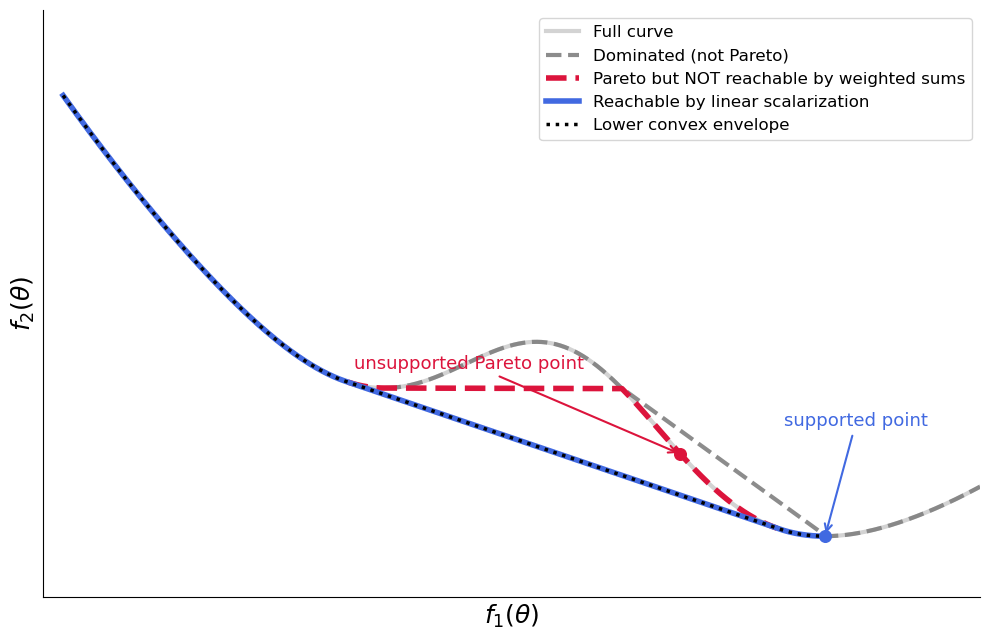

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) Define the curve y = f(x)
#    Replace this with your exact curve if needed.
# ============================================================
def f(x):
    return (
        4.6
        - 0.95 * x
        + 0.18 * (x - 1.3) ** 2
        + 0.75 * np.exp(-((x - 3.15) / 0.75) ** 2)
    )

x = np.linspace(0.7, 5.2, 800)
y = f(x)

# ============================================================
# 2) Compute nondominated points for minimization in (x, y)
#    Since x is increasing, a point is nondominated iff its y
#    is lower than all previous y-values.
# ============================================================
pareto_mask = np.zeros_like(x, dtype=bool)
best_y = np.inf
for i in range(len(x)):
    if y[i] < best_y:
        pareto_mask[i] = True
        best_y = y[i]

x_p = x[pareto_mask]
y_p = y[pareto_mask]

# ============================================================
# 3) Compute supported points = lower convex hull of Pareto set
#    Monotone-chain style test using cross products
# ============================================================
def cross(o, a, b):
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

pts = np.column_stack([x_p, y_p])

lower = []
for p in pts:
    while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
        lower.pop()
    lower.append(tuple(p))

lower = np.array(lower)

# ============================================================
# 4) Classify Pareto points as supported vs unsupported
# ============================================================
supported_mask = np.zeros(len(x_p), dtype=bool)

# mark the exact hull vertices
for i, (xp, yp) in enumerate(zip(x_p, y_p)):
    if np.any(np.isclose(lower[:, 0], xp) & np.isclose(lower[:, 1], yp)):
        supported_mask[i] = True

unsupported_mask = ~supported_mask

# ============================================================
# 5) Plot
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6.5))

# Full curve in light gray
ax.plot(x, y, color="lightgray", linewidth=3, label="Full curve")

# Dominated part (gray dashed)
dominated_mask = ~pareto_mask
ax.plot(
    x[dominated_mask],
    y[dominated_mask],
    linestyle="--",
    linewidth=3,
    color="gray",
    alpha=0.9,
    label="Dominated (not Pareto)"
)

# Unsupported Pareto points
ax.plot(
    x_p[unsupported_mask],
    y_p[unsupported_mask],
    color="crimson",
    linewidth=4,
    linestyle="--",
    label="Pareto but NOT reachable by weighted sums"
)

# Supported Pareto points
ax.plot(
    x_p[supported_mask],
    y_p[supported_mask],
    color="royalblue",
    linewidth=4,
    label="Reachable by linear scalarization"
)

# Lower convex envelope / supporting hull
ax.plot(
    lower[:, 0],
    lower[:, 1],
    "k:",
    linewidth=2.5,
    label="Lower convex envelope"
)

# Annotate one unsupported point if it exists
if np.any(unsupported_mask):
    idx = np.where(unsupported_mask)[0][len(np.where(unsupported_mask)[0]) // 2]
    ax.scatter([x_p[idx]], [y_p[idx]], color="crimson", s=70, zorder=5)
    ax.annotate(
        "unsupported Pareto point",
        xy=(x_p[idx], y_p[idx]),
        xytext=(x_p[idx] - 1.6, y_p[idx] + 0.35),
        fontsize=13,
        color="crimson",
        arrowprops=dict(arrowstyle="->", lw=1.5, color="crimson"),
    )

# Annotate one supported point if it exists
if np.any(supported_mask):
    idx = np.where(supported_mask)[0][-1]
    ax.scatter([x_p[idx]], [y_p[idx]], color="royalblue", s=70, zorder=5)
    ax.annotate(
        "supported point",
        xy=(x_p[idx], y_p[idx]),
        xytext=(x_p[idx] - 0.2, y_p[idx] + 0.45),
        fontsize=13,
        color="royalblue",
        arrowprops=dict(arrowstyle="->", lw=1.5, color="royalblue"),
    )

ax.set_xlabel(r"$f_1(\theta)$", fontsize=18)
ax.set_ylabel(r"$f_2(\theta)$", fontsize=18)
ax.set_xticks([])
ax.set_yticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(0.6, 5.2)
ax.set_ylim(min(y) - 0.25, max(y) + 0.35)

ax.legend(fontsize=12, loc="upper right", frameon=True)
plt.tight_layout()
plt.savefig("pareto_supported_vs_unsupported_exact.png", dpi=300, bbox_inches="tight")
plt.show()